Task 1: Dataset Preparation

Training data shape: (50000, 32, 32, 3)
Training labels shape: (50000, 1)
Testing data shape: (10000, 32, 32, 3)
Testing labels shape: (10000, 1)


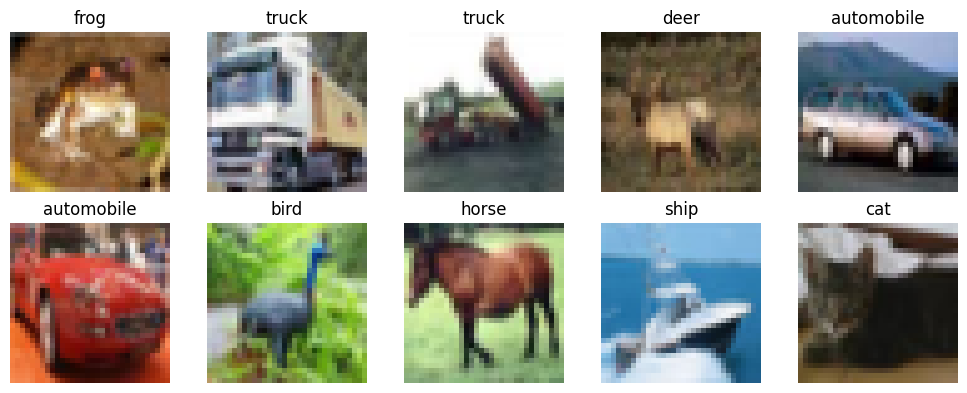

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

x_train_norm = x_train.astype('float32') / 255.0
x_test_norm = x_test.astype('float32') / 255.0

print("Training data shape:", x_train.shape)
print("Training labels shape:", y_train.shape)
print("Testing data shape:", x_test.shape)
print("Testing labels shape:", y_test.shape)

plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150)
plt.show()

Task 2: Transfer Learning Model Setup (MobileNetV2)

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import Input, Resizing, Rescaling, GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical

y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

IMG_SIZE = 96
base_model = MobileNetV2(input_shape=(IMG_SIZE, IMG_SIZE, 3),
                          include_top=False,
                          weights='imagenet')

base_model.trainable = False
inputs = Input(shape=(32, 32, 3))
x = Resizing(IMG_SIZE, IMG_SIZE)(inputs)
x = tf.keras.layers.Lambda(preprocess_input)(x)
x = base_model(x, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
outputs = Dense(10, activation='softmax')(x)

model = Model(inputs, outputs)
model.summary()

print(f"\nTotal parameters: {model.count_params():,}")
print(f"Trainable parameters: {sum([tf.size(w).numpy() for w in model.trainable_weights]):,}")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing (Resizing)             │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)


Total parameters: 2,423,242
Trainable parameters: 165,258


Task 3: Model Training

Epoch 1/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 318s 222ms/step - accuracy: 0.8290 - loss: 0.5059 - val_accuracy: 0.8530 - val_loss: 0.4285
Epoch 2/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 339s 241ms/step - accuracy: 0.8702 - loss: 0.3691 - val_accuracy: 0.8590 - val_loss: 0.3956
Epoch 3/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 328s 233ms/step - accuracy: 0.8916 - loss: 0.3109 - val_accuracy: 0.8620 - val_loss: 0.4016
Epoch 4/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 329s 234ms/step - accuracy: 0.9069 - loss: 0.2631 - val_accuracy: 0.8698 - val_loss: 0.3911
Epoch 5/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 340s 242ms/step - accuracy: 0.9234 - loss: 0.2181 - val_accuracy: 0.8644 - val_loss: 0.4361
Epoch 6/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 360s 227ms/step - accuracy: 0.9357 - loss: 0.1809 - val_accuracy: 0.8722 - val_loss: 0.4248
Epoch 7/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 313s 223ms/step - accuracy: 0.9475 - loss: 0.1472 - val_accuracy: 0.8572 - val_loss: 0.4958
Epoch 8/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 341s 236ms/step - ac

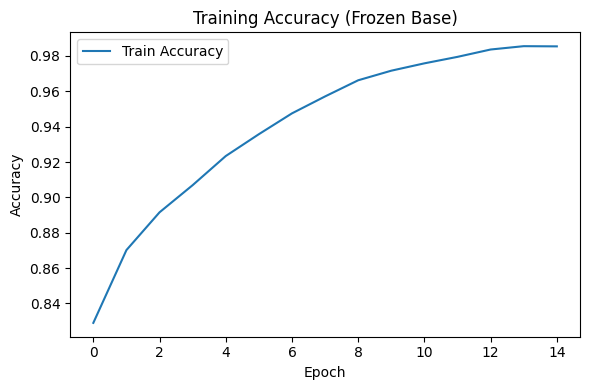

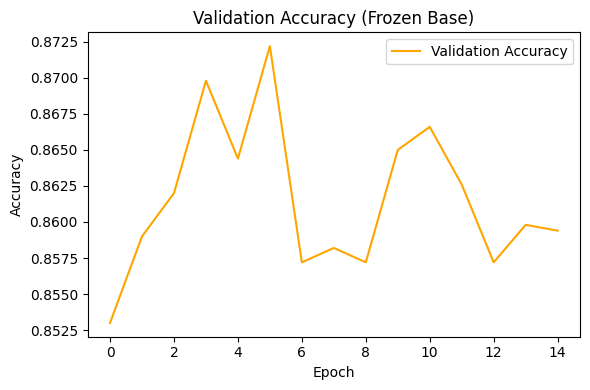

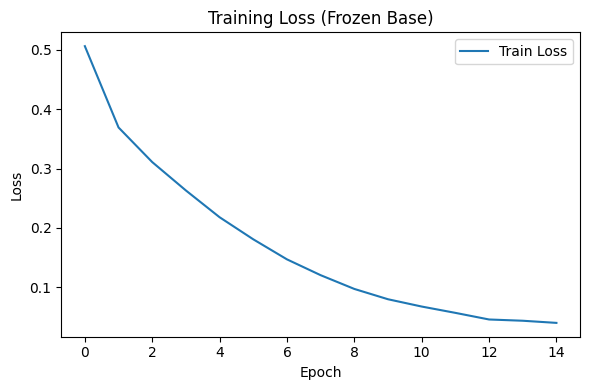

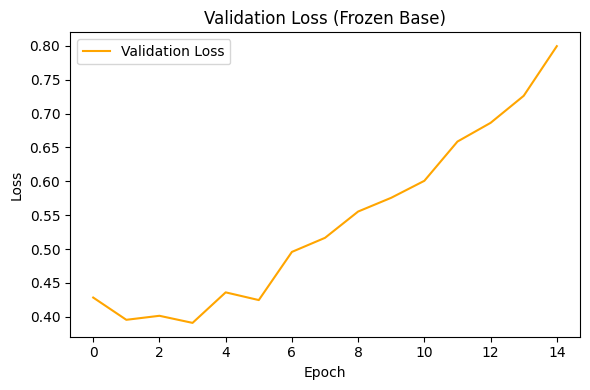


Test Accuracy BEFORE fine-tuning: 0.8542


In [ ]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(x_train, y_train_cat,
                     epochs=15,
                     batch_size=32,
                     validation_split=0.1,
                     verbose=1)

plt.figure(figsize=(6, 4))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.title('Training Accuracy (Frozen Base)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.savefig('training_accuracy.png', dpi=150)
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.title('Validation Accuracy (Frozen Base)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.savefig('validation_accuracy.png', dpi=150)
plt.show()
plt.figure(figsize=(6, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.title('Training Loss (Frozen Base)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.savefig('training_loss.png', dpi=150)
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Validation Loss (Frozen Base)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.savefig('validation_loss.png', dpi=150)
plt.show()
pre_finetune_test_loss, pre_finetune_test_acc = model.evaluate(x_test, y_test_cat, verbose=0)
print(f"\nTest Accuracy BEFORE fine-tuning: {pre_finetune_test_acc:.4f}")

In [ ]:
import tensorflow as tf
import numpy as np
import pandas as pd
import time
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import Input, Resizing, GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

IMG_SIZE = 96

base_model = MobileNetV2(input_shape=(IMG_SIZE, IMG_SIZE, 3),
                          include_top=False,
                          weights='imagenet')
base_model.trainable = False

inputs = Input(shape=(32, 32, 3))
x = Resizing(IMG_SIZE, IMG_SIZE)(inputs)
x = tf.keras.layers.Lambda(preprocess_input)(x)
x = base_model(x, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
outputs = Dense(10, activation='softmax')(x)

model = Model(inputs, outputs)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()
start_time = time.time()
history = model.fit(x_train, y_train_cat, epochs=15, batch_size=32,
                     validation_split=0.1, verbose=1)
frozen_train_time = time.time() - start_time

base_model.trainable = True
fine_tune_at = 100
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

start_time = time.time()
fine_tune_history = model.fit(x_train, y_train_cat, epochs=8, batch_size=32,
                               validation_split=0.1, verbose=1)
finetune_train_time = time.time() - start_time

total_training_time = frozen_train_time + finetune_train_time


y_pred_probs = model.predict(x_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test.flatten()

train_acc = fine_tune_history.history['accuracy'][-1]
test_acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='macro')
rec = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')
total_params = model.count_params()

results_table = pd.DataFrame({
    'Metric': ['Training Accuracy', 'Testing Accuracy', 'Precision', 'Recall',
               'F1-score', 'Training Time (s)', 'Total Parameters'],
    'Value': [f"{train_acc:.4f}", f"{test_acc:.4f}", f"{prec:.4f}", f"{rec:.4f}",
              f"{f1:.4f}", f"{total_training_time:.2f}", f"{total_params:,}"]
})

print(results_table.to_string(index=False))
results_table.to_csv('performance_metrics.csv', index=False)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1210s 7us/step
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing (Resizing)             │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 351s 245ms/step - accuracy: 0.8273 - loss: 0.5048 - val_accuracy: 0.8614 - val_loss: 0.3862
Epoch 2/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 342s 243ms/step - accuracy: 0.8725 - loss: 0.3639 - val_accuracy: 0.8640 - val_loss: 0.3862
Epoch 3/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 351s 250ms/step - accuracy: 0.8920 - loss: 0.3091 - val_accuracy: 0.8668 - val_loss: 0.3771
Epoch 4/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 353s 251ms/step - accuracy: 0.9098 - loss: 0.2582 - val_accuracy: 0.8660 - val_loss: 0.3925
Epoch 5/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 353s 251ms/step - accuracy: 0.9224 - loss: 0.2186 - val_accuracy: 0.8590 - val_loss: 0.4311
Epoch 6/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 372s 244ms/step - accuracy: 0.9373 - loss: 0.1773 - val_accuracy: 0.8708 - val_loss: 0.4316
Epoch 7/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 344s 245ms/step - accuracy: 0.9477 - loss: 0.1451 - val_accuracy: 0.8588 - val_loss: 0.4685
Epoch 8/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 391s 251ms/step - ac